## ¿Qué es la tasa libre de riesgo?

La tasa libre de riesgo (Rf) es el retorno que se obtiene sin asumir riesgo de crédito. 
En la práctica se usa el rendimiento del bono del Tesoro de EE.UU. a 10 años (GS10) 
porque se asume que el gobierno americano nunca incumplirá su deuda.

**Metodología:** usamos el valor actual del GS10 obtenido de la base de datos de la Fed (FRED)

En el modelo CAPM:

$$E(R_i) = R_f + \beta_i \cdot (E(R_m) - R_f)$$

La Rf es el mínimo que cualquier inversión debería retornar.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.db_client import fetch_risk_free_rate

In [3]:
df = fetch_risk_free_rate()
df.head()

,observation_date,rate
0,1953-04-01,2.83
1,1953-05-01,3.05
2,1953-06-01,3.11
3,1953-07-01,2.93
4,1953-08-01,2.95


In [7]:
print(f"Observaciones totales: {len(df)}")
print(f"Desde: {df['observation_date'].min().date()}")
print(f"Hasta: {df['observation_date'].max().date()}")
print(f"\nTasa actual (última observación): {df['rate'].iloc[-1]:.2f}%")
print(f"Tasa promedio histórica:          {df['rate'].mean():.2f}%")
print(f"Tasa mínima histórica:            {df['rate'].min():.2f}%")
print(f"Tasa máxima histórica:            {df['rate'].max():.2f}%")

Observaciones totales: 878
Desde: 1953-04-01
Hasta: 2026-05-01

Tasa actual (última observación): 4.48%
Tasa promedio histórica:          5.53%
Tasa mínima histórica:            0.62%
Tasa máxima histórica:            15.32%


## Evolución histórica

La gráfica muestra cómo la tasa libre de riesgo ha cambiado desde 1953. 
Tres momentos clave:

- **Años 80:** máximo histórico (15.32%) — la Fed subió tasas agresivamente para combatir la inflación de los 70s
- **2020:** mínimo histórico (0.62%) — la Fed bajó tasas a casi cero para estimular la economía durante COVID
- **2022–hoy:** subida rápida para combatir la inflación post-COVID. Tasa actual: 4.48%

**Implicación para el CAPM:** cuando la Rf sube, el costo de capital de todas las empresas sube

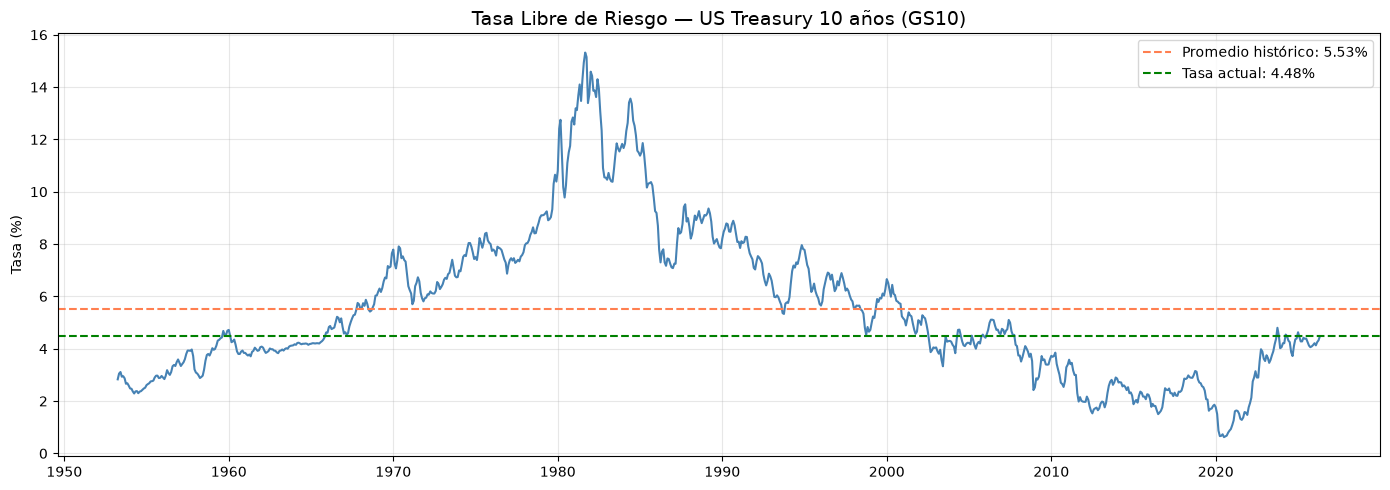

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['observation_date'], df['rate'], color='steelblue', linewidth=1.5)
ax.axhline(df['rate'].mean(), color='coral', linestyle='--', label=f'Promedio histórico: {df["rate"].mean():.2f}%')
ax.axhline(df['rate'].iloc[-1], color='green', linestyle='--', label=f'Tasa actual: {df["rate"].iloc[-1]:.2f}%')

ax.set_title('Tasa Libre de Riesgo — US Treasury 10 años (GS10)', fontsize=14)
ax.set_ylabel('Tasa (%)')
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()